# 03 - TF-IDF, Modeling, Evaluasi, dan Insight

Notebook ini menjalankan feature engineering TF-IDF, split stratified, perbandingan Multinomial Naive Bayes dan Logistic Regression, classification report, confusion matrix, wordcloud, serta top kata review negatif.

In [15]:
from collections import Counter
from pathlib import Path
import json
import joblib
import re
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from wordcloud import WordCloud
import string
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

In [16]:
ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "data" / "processed").is_dir())
DATA_PATH = ROOT / "data" / "processed" / "coretax_reviews_clean.csv"
MODEL_PATH = ROOT / "outputs" / "model"
LABELS = ["negatif", "netral", "positif"]
df = pd.read_csv(DATA_PATH)
X_train, X_test, y_train, y_test = train_test_split(df["clean_text"], df["sentiment"], test_size=0.2, random_state=42, stratify=df["sentiment"])

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
print("Train matrix:", X_train_tfidf.shape)
print("Test matrix:", X_test_tfidf.shape)

models = {"Naive Bayes": MultinomialNB(), "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced")}
results = {}
confusion_matrices = {}
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    prediction = model.predict(X_test_tfidf)
    report = classification_report(y_test, prediction, labels=LABELS, output_dict=True, zero_division=0)
    results[name] = {"accuracy": accuracy_score(y_test, prediction), "f1_macro": f1_score(y_test, prediction, labels=LABELS, average="macro", zero_division=0), "f1_weighted": f1_score(y_test, prediction, labels=LABELS, average="weighted", zero_division=0), "report": report, "prediction": prediction}
    confusion_matrices[name] = confusion_matrix(y_test, prediction, labels=LABELS)

summary = pd.DataFrame({name: {"Akurasi": value["accuracy"], "F1 Macro": value["f1_macro"], "F1 Weighted": value["f1_weighted"]} for name, value in results.items()}).T
summary

Train matrix: (6285, 5000)
Test matrix: (1572, 5000)


,Akurasi,F1 Macro,F1 Weighted
Naive Bayes,0.886132,0.453572,0.853433
Logistic Regression,0.853053,0.555291,0.866966


=== Naive Bayes ===
              precision    recall  f1-score   support

     negatif       0.89      1.00      0.94      1348
      netral       0.00      0.00      0.00        40
     positif       0.89      0.28      0.42       184

    accuracy                           0.89      1572
   macro avg       0.59      0.42      0.45      1572
weighted avg       0.86      0.89      0.85      1572

=== Logistic Regression ===
              precision    recall  f1-score   support

     negatif       0.95      0.89      0.92      1348
      netral       0.07      0.15      0.10        40
     positif       0.59      0.71      0.65       184

    accuracy                           0.85      1572
   macro avg       0.54      0.59      0.56      1572
weighted avg       0.88      0.85      0.87      1572



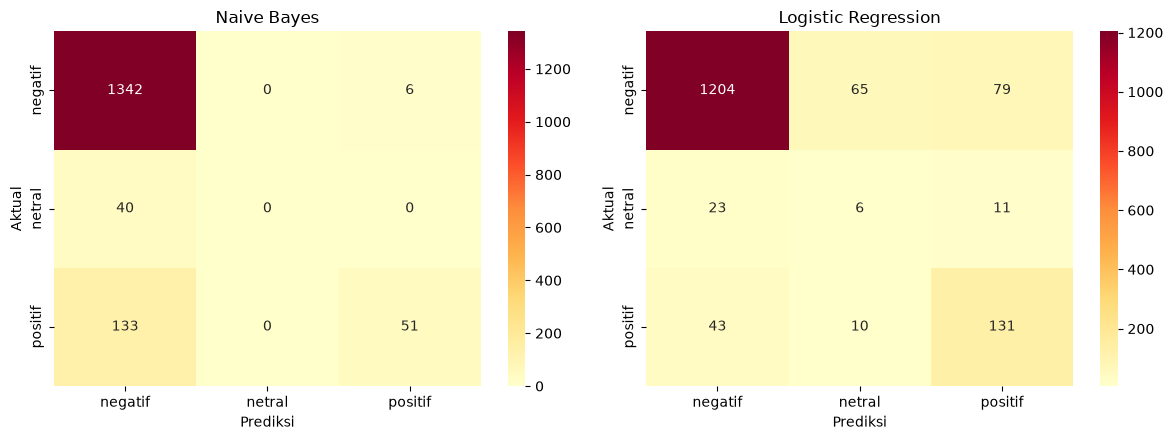

Model terpilih: Logistic Regression
Alasan: F1 macro=0.555, akurasi=0.853


['/home/titan/github/coretax-sentiment-analysis/outputs/model/tfidf_vectorizer_from_notebook.pkl']

In [17]:
# Classification report per model: metrik per kelas lebih informatif pada data imbalance.
for name, value in results.items():
    print(f"=== {name} ===")
    print(classification_report(y_test, value["prediction"], labels=LABELS, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (name, matrix) in zip(axes, confusion_matrices.items()):
    sns.heatmap(matrix, annot=True, fmt="d", cmap="YlOrRd", xticklabels=LABELS, yticklabels=LABELS, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Prediksi")
    ax.set_ylabel("Aktual")
plt.tight_layout()
plt.show()

# Pilih model berdasarkan F1 macro, kemudian akurasi.
selected_name = max(results, key=lambda name: (results[name]["f1_macro"], results[name]["accuracy"]))
selected_model = models[selected_name]
print(f"Model terpilih: {selected_name}")
print(f"Alasan: F1 macro={results[selected_name]['f1_macro']:.3f}, akurasi={results[selected_name]['accuracy']:.3f}")

MODEL_PATH.mkdir(parents=True, exist_ok=True)
joblib.dump(selected_model, MODEL_PATH / "sentiment_model_from_notebook.pkl")
joblib.dump(vectorizer, MODEL_PATH / "tfidf_vectorizer_from_notebook.pkl")

## Uji Prediksi Review Baru

Jalankan cell berikut setelah cell training. Ganti isi `review_baru` untuk menguji kalimat lain.

In [ ]:
# Jika cell training belum dijalankan, gunakan artefak model yang sudah tersimpan.
if "ROOT" not in globals():
    ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "data" / "processed").is_dir())
if "MODEL_PATH" not in globals():
    MODEL_PATH = ROOT / "outputs" / "model"
if "vectorizer" not in globals():
    vectorizer_path = next(path for path in [MODEL_PATH / "tfidf_vectorizer.pkl", MODEL_PATH / "tfidf_vectorizer_from_notebook.pkl"] if path.exists())
    vectorizer = joblib.load(vectorizer_path)
if "selected_model" not in globals():
    model_path = next(path for path in [MODEL_PATH / "sentiment_model.pkl", MODEL_PATH / "sentiment_model_from_notebook.pkl"] if path.exists())
    selected_model = joblib.load(model_path)

slang_normalization = {"bgt": "banget", "ga": "tidak", "gak": "tidak", "gk": "tidak", "nggak": "tidak", "ngga": "tidak", "aja": "saja", "apk": "aplikasi", "blm": "belum", "belom": "belum", "bener": "benar", "krn": "karena", "lg": "lagi", "msh": "masih", "ribet": "rumit", "udh": "sudah", "udah": "sudah", "yg": "yang"}
stopword_remover = StopWordRemoverFactory().create_stop_word_remover()

def prepare_new_review(text):
    text = str(text).lower()
    text = re.sub(r"http\\S+|www\\S+|@\\w+|#\\w+", " ", text)
    text = re.sub(r"[0-9]+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"[^a-z\\s]", " ", text)
    text = re.sub(r"(.)\\1{2,}", r"\\1\\1", text)
    text = re.sub(r"\\s+", " ", text).strip()[:2000]
    text = " ".join(slang_normalization.get(token, token) for token in text.split())
    return stopword_remover.remove(text)

review_baru = "aplikasi tidak bisa login dan server error"
# review_baru = "aplikasi sangat membantu"
review_bersih = prepare_new_review(review_baru)
review_vector = vectorizer.transform([review_bersih])
prediksi = selected_model.predict(review_vector)[0]

print("Review asli          :", review_baru)
print("Setelah preprocessing:", review_bersih)
print("Prediksi sentimen    :", prediksi.upper())

if hasattr(selected_model, "predict_proba"):
    probabilities = selected_model.predict_proba(review_vector)[0]
    probability_table = pd.DataFrame({"sentiment": selected_model.classes_, "probability": probabilities})
    probability_table["probability"] = (probability_table["probability"] * 100).round(2).astype(str) + "%"
    display(probability_table.sort_values("probability", ascending=False))

Review asli          : aplikasi sangat membantu
Setelah preprocessing: aplikasi sangat membantu
Prediksi sentimen    : POSITIF


,sentiment,probability
2,positif,90.35%
0,negatif,7.99%
1,netral,1.65%


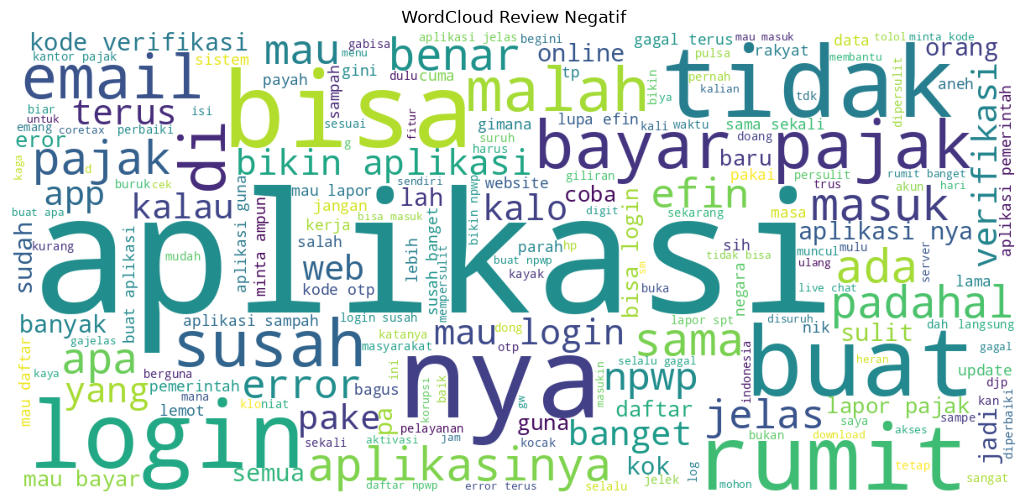

354

In [19]:
# Insight eksploratif: kata dominan dalam review negatif.
negative_words = Counter(" ".join(df.loc[df["sentiment"].eq("negatif"), "clean_text"]).split())
top_negative_words = pd.DataFrame(negative_words.most_common(20), columns=["word", "count"])
top_negative_words.to_csv(ROOT / "outputs" / "top_negative_words_from_notebook.csv", index=False)
top_negative_words

wordcloud_text = " ".join(df.loc[df["sentiment"].eq("negatif"), "clean_text"])
wordcloud = WordCloud(width=1200, height=550, background_color="white", colormap="viridis").generate(wordcloud_text)
plt.figure(figsize=(13, 6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("WordCloud Review Negatif")
plt.show()

metrics_for_export = {name: {key: value[key] for key in ["accuracy", "f1_macro", "f1_weighted"]} for name, value in results.items()}
(ROOT / "outputs" / "metrics_from_notebook.json").write_text(json.dumps({"selected": selected_name, "metrics": metrics_for_export}, indent=2), encoding="utf-8")